In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [ ]:
def train_and_evaluate(X_train, y_train, X_test, y_test, dataset_name, epochs=20):
    # Convertir etiquetas a one-hot
    num_classes = y_train.shape[1]

    # Definir modelo
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"\n--- Resumen del modelo para {dataset_name} ---")
    model.summary()

    # Entrenamiento
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=64,
        validation_split=0.2,
        verbose=1
    )

    # Evaluación
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{dataset_name} → Test Loss: {loss:.4f} — Test Accuracy: {acc:.4f}")

    # Gráficas
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{dataset_name} Accuracy')
    plt.xlabel('Época'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{dataset_name} Loss')
    plt.xlabel('Época'); plt.ylabel('Loss'); plt.legend()

    plt.show()

In [ ]:
from tensorflow.keras.datasets import mnist

# Cargar y preprocesar
(X, y), (X_test, y_test) = mnist.load_data()
# Escalar y aplanar (28×28 → 784)
X = X.reshape(-1, 28*28).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28*28).astype('float32') / 255.0
y_cat = to_categorical(y)
y_test_cat = to_categorical(y_test)

# Split adicional de validación interno si se desea (ya se hace en la función)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



--- Resumen del modelo para MNIST ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8261 - loss: 0.6041 - val_accuracy: 0.9457 - val_loss: 0.1806
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9559 - loss: 0.1509 - val_accuracy: 0.9535 - val_loss: 0.1488
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9700 - loss: 0.0979 - val_accuracy: 0.9659 - val_loss: 0.1103
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9794 - loss: 0.0683 - val_accuracy: 0.9660 - val_loss: 0.1117
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9846 - loss: 0.0502 - val_accuracy: 0.9679 - val_loss: 0.1039
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9858 - loss: 0.0457 - val_accuracy: 0.9701 - val_loss: 0.1012
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9886 - loss: 0.0353 - val_accuracy: 0.9741 - val_loss: 0.0903
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9918 - loss: 0.0279 - val_accuracy: 0.

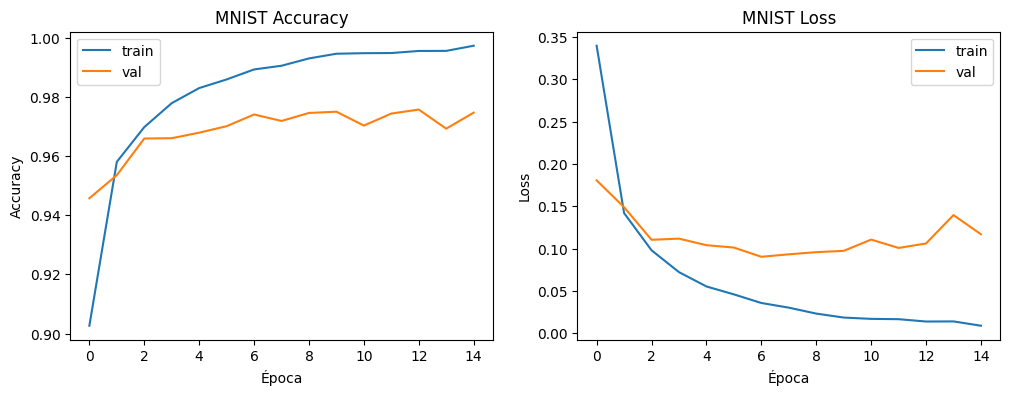

In [ ]:
train_and_evaluate(X_train, y_train, X_test, y_test_cat, 'MNIST', epochs=15)

In [ ]:
from tensorflow.keras.datasets import fashion_mnist

# Cargar y preprocesar
(X, y), (X_test, y_test) = fashion_mnist.load_data()
X = X.reshape(-1, 28*28).astype('float32') / 255.0
X_test = X_test.reshape(-1, 28*28).astype('float32') / 255.0
y_cat = to_categorical(y)
y_test_cat = to_categorical(y_test)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step



--- Resumen del modelo para Fashion-MNIST ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7457 - loss: 0.7456 - val_accuracy: 0.8446 - val_loss: 0.4308
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8522 - loss: 0.4181 - val_accuracy: 0.8557 - val_loss: 0.4108
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8693 - loss: 0.3619 - val_accuracy: 0.8729 - val_loss: 0.3463
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8740 - loss: 0.3448 - val_accuracy: 0.8715 - val_loss: 0.3465
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8835 - loss: 0.3203 - val_accuracy: 0.8770 - val_loss: 0.3305
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8906 - loss: 0.3031 - val_accuracy: 0.8780 - val_loss: 0.3354
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8966 - loss: 0.2821 - val_accuracy: 0.8809 - val_loss: 0.3240
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8997 - loss: 0.2686 - val_accuracy: 0.

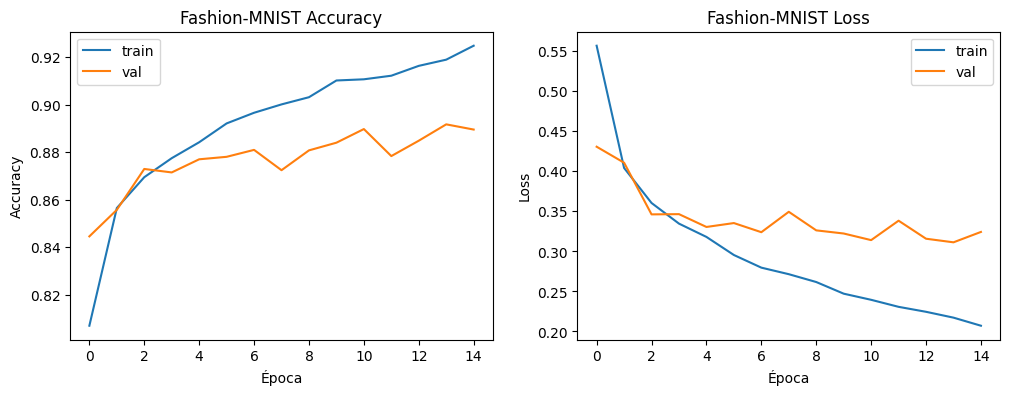

In [ ]:
train_and_evaluate(X_train, y_train, X_test, y_test_cat, 'Fashion-MNIST', epochs=15)

In [ ]:
from tensorflow.keras.datasets import cifar10

# Cargar y preprocesar
(X, y), (X_test, y_test) = cifar10.load_data()
# Aplanar imágenes 32×32×3 → 3072
X = X.reshape(-1, 32*32*3).astype('float32') / 255.0
X_test = X_test.reshape(-1, 32*32*3).astype('float32') / 255.0
y_cat = to_categorical(y.flatten())
y_test_cat = to_categorical(y_test.flatten())

X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, random_state=42
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step



--- Resumen del modelo para CIFAR-10 ---


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,250 (1.53 MB)

 Trainable params: 402,250 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2554 - loss: 2.0537 - val_accuracy: 0.3501 - val_loss: 1.8051
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.3682 - loss: 1.7715 - val_accuracy: 0.3313 - val_loss: 1.8317
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3908 - loss: 1.7069 - val_accuracy: 0.3934 - val_loss: 1.6891
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4168 - loss: 1.6456 - val_accuracy: 0.4131 - val_loss: 1.6616
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.4250 - loss: 1.6101 - val_accuracy: 0.4089 - val_loss: 1.6440
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.4468 - loss: 1.5682 - val_accuracy: 0.4144 - val_loss: 1.6504
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.4457 - loss: 1.5661 - val_accuracy: 0.4270 - val_loss: 1.5978
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4625 - loss: 1.5182 - val_ac

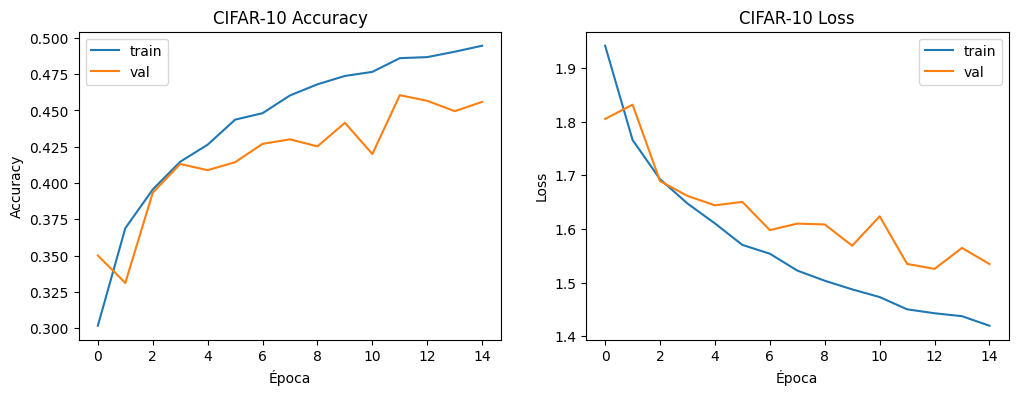

In [ ]:
train_and_evaluate(X_train, y_train, X_test, y_test_cat, 'CIFAR-10', epochs=15)